# Delta dmo features by day

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import DMOLSTM, ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.model import lstm_regression
from src.train import TrainRegression
from src.pipeline.dmo.dmo_into_dataloader import dmo_into_dataloader

import matplotlib.pyplot as plt

import numpy as np
import torch

In [2]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=175,
    hidden_size=128,
    num_layers=2,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [5]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [6]:
print(dmo_labels)

tensor([[[ 7],
         [15],
         [23],
         [13],
         [18]],

        [[ 9],
         [-1],
         [-1],
         [-1],
         [-1]],

        [[11],
         [17],
         [18],
         [20],
         [19]],

        ...,

        [[20],
         [12],
         [ 2],
         [29],
         [-1]],

        [[13],
         [-1],
         [-1],
         [18],
         [-1]],

        [[24],
         [-1],
         [-1],
         [-1],
         [-1]]])


In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [8]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [9]:
dmo_data = dmo_data.flatten(start_dim=2, end_dim=3)

In [10]:
dmo_data = dmo_data.flatten(start_dim=0, end_dim=1)
dmo_data = dmo_data.unsqueeze(1)
dmo_labels = dmo_labels.flatten(start_dim=0, end_dim=1)
dmo_labels = dmo_labels.unsqueeze(dim=1)
print(dmo_data.shape)
print(dmo_labels.shape)

torch.Size([1400, 1, 175])
torch.Size([1400, 1, 1])


In [11]:
transforms = (None, None)
training_dl, testing_dl = dmo_into_dataloader(dmo_data, dmo_labels, batch_size=16, transforms=transforms)

In [12]:
model = DMOLSTM(config).to(device=device)
optimiser = config.optimiser(model.parameters(), lr=config.learning_rate)

trainer = TrainRegression(
    model,
    optimiser,
    config,
    training_dl,
    testing_dl,
    device,
    verbose=True,
)

trainer.train_loop()
prediction, actual = trainer.test_loop()


Testing loss: 0.08758882102039126


In [13]:
print(prediction)
print(actual)

[tensor([[0.9067]]), tensor([[0.3031]]), tensor([[0.6358]]), tensor([[0.5832]]), tensor([[0.6077]]), tensor([[0.4262]]), tensor([[0.4457]]), tensor([[0.6514]]), tensor([[0.3850]]), tensor([[0.6523]]), tensor([[0.6375]]), tensor([[0.5141]]), tensor([[0.5336]]), tensor([[0.1468]]), tensor([[0.6622]]), tensor([[0.3715]]), tensor([[0.6648]]), tensor([[0.1426]]), tensor([[0.6538]]), tensor([[0.0089]]), tensor([[0.5552]]), tensor([[0.3618]]), tensor([[0.7912]]), tensor([[0.6451]]), tensor([[0.4503]]), tensor([[0.6160]]), tensor([[0.4703]]), tensor([[0.6673]]), tensor([[0.3922]]), tensor([[0.6297]]), tensor([[0.3175]]), tensor([[0.2691]]), tensor([[0.1398]]), tensor([[0.9721]]), tensor([[0.7546]]), tensor([[0.9553]]), tensor([[0.5948]]), tensor([[0.6327]]), tensor([[0.8191]]), tensor([[0.8883]]), tensor([[0.7402]]), tensor([[0.8770]]), tensor([[0.6360]]), tensor([[0.5102]]), tensor([[0.6371]]), tensor([[0.4459]]), tensor([[0.6078]]), tensor([[0.6441]]), tensor([[0.4022]]), tensor([[0.5562]]),

All metrics: {'accuracy': 0.23214285714285715, 'Mean Squared Error': 0.0880420133471489, 'Mean Absolute Error': 0.24312078952789307, 'R^2': -0.5714298486709595}


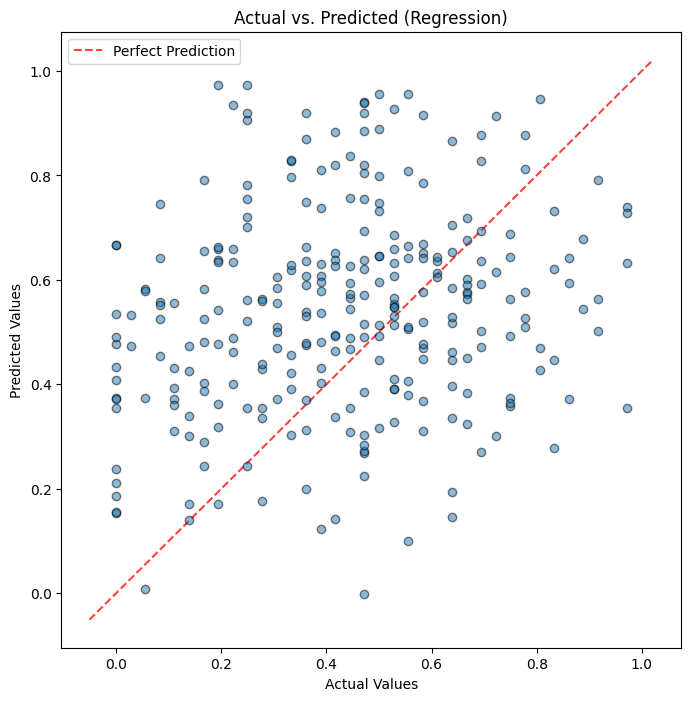

In [14]:
from src.evaluation import Evaluation

actual_values = torch.Tensor(actual)
predicted_values = torch.Tensor(prediction)

evaluation = Evaluation(predicted_values, actual_values)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
